### Build a Basic Chatbot with LangGraph (GRAPH API)

In [2]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [ ]:
class State(TypedDict):
  # Messages have the type "list". The `add_messages` function
  # in the annotation defines how this state key should be updated
  # (in this case, it appends messages to the list, rather than overwriting them)
  messages: Annotated[list, add_messages]

  

In [5]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [6]:
from langchain_groq import ChatGroq

llm= ChatGroq(model="qwen/qwen3.6-27b")

In [7]:
## Create Node (Chatbot)
def chatbot(state:State):
  return {"messages": [llm.invoke(state["messages"])]}

In [9]:
## Create Graph
graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("chatbot", chatbot)

## Adding edges
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

## compile the graph
graph = graph_builder.compile()

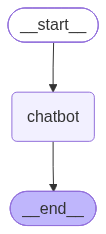

In [10]:
## Visulize Graph
from IPython.display import Image, display

try:
  display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
  pass

In [14]:
# Call the chatbot
response = graph.invoke({"messages": "Explian LLM"})

In [16]:
response["messages"][-1].content

'\n<think>\nHere\'s a thinking process:\n\n1.  **Understand User Input:** The user typed "Explian LLM" (note the typo: "Explian" should be "Explain"). They want an explanation of what LLMs are.\n\n2.  **Identify Core Concept:** LLM stands for Large Language Model. It\'s a type of artificial intelligence that processes and generates human-like text.\n\n3.  **Key Components to Cover:**\n   - Definition/What it stands for\n   - How it works (basic architecture/training)\n   - Key characteristics (scale, training data, parameters)\n   - Common applications\n   - Limitations/Challenges\n   - Examples\n   - Keep it clear, structured, and accessible\n\n4.  **Draft - Section by Section:**\n   *(Mental Refinement)*\n   - **Definition:** LLM = Large Language Model. AI systems trained on massive amounts of text to understand and generate human language.\n   - **How it Works:** Based on neural networks (specifically transformers). Trained on huge datasets (books, websites, code, etc.). Learns patt

In [19]:
for event in graph.stream({"messages": "Hi How are you?"}):
  for value in event.values():
    print(value["messages"][-1].content)


<think>
Here's a thinking process:

1.  **Analyze User Input:**
   - User says: "Hi How are you?"
   - This is a standard greeting and a casual question about my well-being.

2.  **Identify Key Components:**
   - Greeting: "Hi"
   - Question: "How are you?"
   - Tone: Friendly, casual

3.  **Determine Response Strategy:**
   - Acknowledge the greeting
   - Respond to the question politely and positively
   - Keep it concise
   - Offer assistance
   - Maintain a friendly, helpful tone

4.  **Draft Response (Mental):**
   Hi! I'm doing well, thank you for asking. How are you doing today? Is there anything I can help you with?

5.  **Refine Response:**
   - Check tone: Friendly and professional
   - Check length: Concise
   - Check relevance: Directly addresses the greeting and question
   - Add value: Offers help
   - Matches AI persona: Helpful, polite, ready to assist

   The draft looks solid. No changes needed.

6.  **Final Output Generation:** (matches the refined draft)
   "Hi! I'

## Chatbot with Tools

In [21]:
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=2)

tavily_tool.invoke("WHat is langgraph")

{'query': 'WHat is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] Agent systems: LangGraph provides a framework for building agent-based systems, which can be used in applications such as robotics, autonomous vehicles or video games.\n\nLLM applications: By using LangGraph’s capabilities, developers can build more sophisticated AI models that learn and improve over time. Norweg

In [22]:
## Custom function (tool)

def multiply(a:int, b:int)->int:
  """Multiply a and b

  Args:
    a (int): first int
    b (int): second int

  Returns
    int: output int
  """
  return a * b

In [23]:
## Create tools list
tools=[tavily_tool, multiply]

In [25]:
## Bind LLM with tools
llm_with_tools=llm.bind_tools(tools)

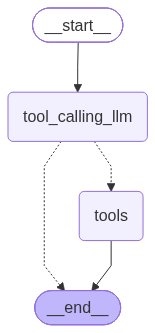

In [26]:
## State Graph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
  return {"messages": [llm_with_tools.invoke(state["messages"])]}

## Graph
builder=StateGraph(State)

## Add nodes
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Add edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
  "tool_calling_llm",
  # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
  # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
  tools_condition
)
builder.add_edge("tools", END)

## Compile the graph
graph = builder.compile()

# Display the graph
display(Image(graph.get_graph().draw_mermaid_png()))

In [28]:
# Call the chatbot
response = graph.invoke({"messages": "What is recent ai news?"})

In [29]:
response["messages"][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.youtube.com/watch?v=X8K1bW-XfL8", "title": "OpenAI\'s GPT-6 \'Doug\', Qwen 4.0 WILL BE INSANE ...", "content": "# OpenAI\'s GPT-6 \'Doug\', Qwen 4.0 WILL BE INSANE, GPT-Image-3.0?, RIP Gemini, & More! HUGE AI NEWS!\\n## WorldofAI\\n231000 subscribers\\n323 likes\\n\\n### Description\\n6862 views\\nPosted: 10 Aug 2026\\nIf you\'re building AI agents or AI-powered apps that need web data, check out Context.dev. One API replaces multiple web intelligence tools, so you can spend less time building infrastructure and more time shipping. \\n\\n🚨 HUGE AI NEWS: OpenAI’s next wave of models could be even crazier than expected. We’re breaking down the mysterious “Doug” codename and what it could mean for GPT-6/Astra, alongside a new mystery Qwen model called “Kiana” that is already producing some insane 3D coding generations. 🤯 [...] 📌 LINKS & RESOURCES\\nWorld of AI Benchmark

In [30]:
for m in response["messages"]:
  m.pretty_print()

================================ Human Message =================================

What is recent ai news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (e9ncv8jxf)
 Call ID: e9ncv8jxf
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: week
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.youtube.com/watch?v=X8K1bW-XfL8", "title": "OpenAI's GPT-6 'Doug', Qwen 4.0 WILL BE INSANE ...", "content": "# OpenAI's GPT-6 'Doug', Qwen 4.0 WILL BE INSANE, GPT-Image-3.0?, RIP Gemini, & More! HUGE AI NEWS!\n## WorldofAI\n231000 subscribers\n323 likes\n\n### Description\n6862 views\nPosted: 10 Aug 2026\nIf you're building AI agents or AI-powered apps that need web data, check out Context.dev. One API replaces multiple web in

In [32]:
response = graph.invoke({"messages": "What is 2 multiply by three"})
for m in response["messages"]:
  m.pretty_print()

================================ Human Message =================================

What is 2 multiply by three
================================== Ai Message ==================================
Tool Calls:
  multiply (e32x7fvpt)
 Call ID: e32x7fvpt
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


## ReAct Agent Archietecture

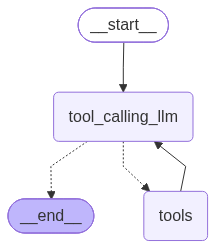

In [33]:
## State Graph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
  return {"messages": [llm_with_tools.invoke(state["messages"])]}

## Graph
builder=StateGraph(State)

## Add nodes
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Add edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
  "tool_calling_llm",
  # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
  # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
  tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

## Compile the graph
graph = builder.compile()

# Display the graph
display(Image(graph.get_graph().draw_mermaid_png()))

In [34]:
response = graph.invoke({"messages": "Give me the recent ai news and then mutiply 8 by 9"})
for m in response["messages"]:
  m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then mutiply 8 by 9
================================== Ai Message ==================================
Tool Calls:
  tavily_search (3yv0296cz)
 Call ID: 3yv0296cz
  Args:
    query: recent AI news
    search_depth: basic
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://mynews13.com/fl/orlando/inside-city-hall/2026/08/07/reporter-looks-at-the-latest-ai-news", "title": "Reporter looks at the latest AI news", "content": "Artificial intelligence was in the political headlines this week with the White House finalizing a framework for how to regulate the most advanced AI models.\n\nOther recent headlines have raised profound issues of safety and security with AI models.\n\nVeronic

## Adding Memory In Agentic Graph

In [35]:
response = graph.invoke({"messages": "Hi I am Nitish"})
for m in response["messages"]:
  m.pretty_print()

================================ Human Message =================================

Hi I am Nitish
================================== Ai Message ==================================

Hello Nitish! Nice to meet you. How can I help you today?


In [36]:
response = graph.invoke({"messages": "What is my name"})
for m in response["messages"]:
  m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================

I don't have access to personal information about you, so I don't know your name. If you'd like to tell me what to call you, I'd be happy to use it in our conversation!


### Adding Memory in Agentic Graph

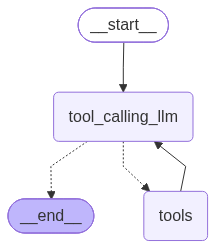

In [39]:
## State Graph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

## Create Memory
memory=MemorySaver()

## Node definition
def tool_calling_llm(state:State):
  return {"messages": [llm_with_tools.invoke(state["messages"])]}

## Graph
builder=StateGraph(State)

## Add nodes
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Add edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
  "tool_calling_llm",
  # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
  # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
  tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

## Compile the graph
graph = builder.compile(checkpointer=memory)

# Display the graph
display(Image(graph.get_graph().draw_mermaid_png()))

In [42]:
# To use the langgraph memory you need to pass this config with unique thread id
config={"configurable": {"thread_id": "1"}}

response = graph.invoke({"messages": "Hi I am Nitish"}, config=config)
for m in response["messages"]:
  m.pretty_print()

================================ Human Message =================================

Hi I am Nitish
================================== Ai Message ==================================

Hello Nitish! How can I help you today?


In [43]:
response = graph.invoke({"messages": "What is my name"}, config=config)
for m in response["messages"]:
  m.pretty_print()

================================ Human Message =================================

Hi I am Nitish
================================== Ai Message ==================================

Hello Nitish! How can I help you today?
================================ Human Message =================================

What is my name
================================== Ai Message ==================================

Your name is Nitish.


## Streaming in LangGraph

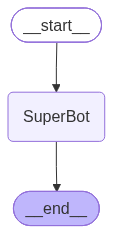

In [47]:
## State Graph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

## Create Memory
memory=MemorySaver()

## Node definition
def superbot(state:State):
  return {"messages": [llm_with_tools.invoke(state["messages"])]}

## Graph
builder=StateGraph(State)

## Add nodes
builder.add_node("SuperBot", superbot)

## Add edges
builder.add_edge(START, "SuperBot")
builder.add_edge("SuperBot", END)

## Compile the graph
graph = builder.compile(checkpointer=memory)

# Display the graph
display(Image(graph.get_graph().draw_mermaid_png()))

In [49]:
## Invocation
config = {"configurable": {"thread_id": "2"}}
graph.invoke({"messages": "Hi, My name is Nitish and I like cricket"}, config)

{'messages': [HumanMessage(content='Hi, My name is Nitish and I like cricket', additional_kwargs={}, response_metadata={}, id='cc77b456-2fb0-4fc5-b072-c756766a8716'),
  AIMessage(content="Hello Nitish! It's nice to meet you. Cricket is a fantastic sport with such a passionate fan base. Do you have a favorite team or player you follow?", additional_kwargs={'reasoning_content': 'Thinking Process:\n\n1.  **Analyze the User\'s Input**: The user says "Hi, My name is Nitish and I like cricket".\n2.  **Identify the Intent**: This is a greeting and a statement of personal preference (interest in cricket).\n3.  **Determine the Response**:\n    *   Acknowledge the user\'s name (Nitish).\n    *   Acknowledge the interest (cricket).\n    *   Be friendly and conversational.\n    *   (Optional) Ask a follow-up question related to cricket to keep the conversation going (e.g., favorite team, player, format).\n4.  **Check Tool Availability**:\n    *   `tavily_search`: Not needed for a simple greeting.\

### Streaming
Methods: .stream() and .astream()
- These methods are sync and async methods for streaming back results.

Additional parameteres in streaming nodes for graph state.

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

In [50]:
## create a thread & use updates stream mode
config={"configurable": {"thread_id": "3"}}

for chunk in graph.stream({'messages': "Hi, My name is Nitish and I like cricket"}, config, stream_mode="updates"):
  print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Hello Nitish! It's nice to meet you.\n\nCricket is a fantastic sport with a lot of strategy and excitement. Do you have a favorite team or player? Or do you prefer a specific format, like Test matches, ODIs, or T20s?", additional_kwargs={'reasoning_content': 'Thinking Process:\n\n1.  **Analyze the User\'s Input:** The user says, "Hi, My name is Nitish and I like cricket".\n2.  **Identify the Intent:** The user is introducing themselves and stating a personal interest. This is a conversational opener.\n3.  **Determine the Role:** I am an AI assistant. I should respond politely, acknowledge the user\'s name, and engage with their interest (cricket).\n4.  **Formulate the Response:**\n    *   Greet Nitish.\n    *   Acknowledge the interest in cricket.\n    *   Ask a follow-up question to keep the conversation going (e.g., favorite team, player, format).\n5.  **Check Tools:** No tools (search, math) are needed for a simple greeting.\n6.  **Draft

In [52]:
## create a thread & use values stream mode
# config={"configurable": {"thread_id": "3"}}

for chunk in graph.stream({'messages': "Hi, My name is Nitish and I like cricket"}, config, stream_mode="values"):
  print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Nitish and I like cricket', additional_kwargs={}, response_metadata={}, id='0211458e-5c6c-47aa-9156-a3fc871d1d02'), AIMessage(content="Hello Nitish! It's nice to meet you.\n\nCricket is a fantastic sport with a lot of strategy and excitement. Do you have a favorite team or player? Or do you prefer a specific format, like Test matches, ODIs, or T20s?", additional_kwargs={'reasoning_content': 'Thinking Process:\n\n1.  **Analyze the User\'s Input:** The user says, "Hi, My name is Nitish and I like cricket".\n2.  **Identify the Intent:** The user is introducing themselves and stating a personal interest. This is a conversational opener.\n3.  **Determine the Role:** I am an AI assistant. I should respond politely, acknowledge the user\'s name, and engage with their interest (cricket).\n4.  **Formulate the Response:**\n    *   Greet Nitish.\n    *   Acknowledge the interest in cricket.\n    *   Ask a follow-up question to keep the conversati

In [ ]:
## create a thread & use updates stream mode
config={"configurable": {"thread_id": "4"}}

for chunk in graph.stream({'messages': "Hi, My name is Nitish and I like cricket"}, config, stream_mode="updates"):
  print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Hello Nitish! It's great to meet you.\n\nThat's awesome that you like cricket! It's such an exciting sport with a huge following. Do you have a favorite team or player that you follow?", additional_kwargs={'reasoning_content': 'Thinking Process:\n\n1.  **Analyze the User\'s Input**: The user is introducing themselves as "Nitish" and stating a preference for the sport "cricket".\n2.  **Determine the Intent**: This is a conversational greeting and sharing personal information.\n3.  **Check Available Tools**:\n    *   `tavily_search`: Search engine. Not needed for a simple greeting unless I want to look up cricket stats, but the user didn\'t ask a question.\n    *   `multiply`: Math tool. Not relevant here.\n4.  **Formulate Response**:\n    *   Acknowledge the name (Nitish).\n    *   Acknowledge the interest (cricket).\n    *   Respond politely and conversationally.\n5.  **Drafting the response**: "Hello Nitish! Nice to meet you. Cricket is a 

In [54]:
## create a thread & use values stream mode
# config={"configurable": {"thread_id": "4"}}

for chunk in graph.stream({'messages': "I also like football."}, config, stream_mode="values"):
  print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Nitish and I like cricket', additional_kwargs={}, response_metadata={}, id='20d9061d-fb00-40b8-a3be-44090b932fef'), AIMessage(content="Hello Nitish! It's great to meet you.\n\nThat's awesome that you like cricket! It's such an exciting sport with a huge following. Do you have a favorite team or player that you follow?", additional_kwargs={'reasoning_content': 'Thinking Process:\n\n1.  **Analyze the User\'s Input**: The user is introducing themselves as "Nitish" and stating a preference for the sport "cricket".\n2.  **Determine the Intent**: This is a conversational greeting and sharing personal information.\n3.  **Check Available Tools**:\n    *   `tavily_search`: Search engine. Not needed for a simple greeting unless I want to look up cricket stats, but the user didn\'t ask a question.\n    *   `multiply`: Math tool. Not relevant here.\n4.  **Formulate Response**:\n    *   Acknowledge the name (Nitish).\n    *   Acknowledge the intere

In [ ]:
## create a thread & use updates stream mode with astream events
config={"configurable": {"thread_id": "5"}}

async for chunk in graph.astream_events({'messages': "Hi, My name is Nitish and I like cricket"}, config, stream_mode="updates"):
  print(chunk)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi, My name is Nitish and I like cricket'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019ffc5a-7881-7963-844c-53f9c2e0feb0', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi, My name is Nitish and I like cricket', additional_kwargs={}, response_metadata={}, id='1a61f181-25df-4141-abe5-7e5b5634d18f')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019ffc5a-7996-7763-bfb5-8dfe7ea75714', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:69b79741-4ce3-f4b5-74a2-5ea7dcee23c2'}, 'parent_ids': ['019ffc5a-7881-7963-844c-53f9c2e0feb0']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessag